# Exact Diagonalization

Exact diagonalization is a numerical method that involves directly solving for the eigenvalues and eigenvectors of the Hamiltonian. In this instance, we will use this method to understand the $k$ interaction by turning off the the $J$ and $h$ parameters:

$$ \mathcal{H_k} = \sum_i k_R(\sigma_i^x \sigma_{i+2}^y- \sigma_i^z\sigma_{i+1}^y\sigma_{i+2}^x)+k_L(\sigma_i^x\sigma_{i+1}^y\sigma_{i+2}^z - \sigma_{i}^y\sigma_{i+2}^x) $$

P.S. Do NOT use odd system sizes, everything breaks because of the way that the polarized boundary conditions work.

# ED Implementation using QuSpin

In [47]:
import gc
import shutil

shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states")
shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values")

gc.collect()


6124

In [ ]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ed_utils import *


# try breaking different symmetries
L        = 8
J        = 0

start    = 0.05
end      = 0.3
step     = 0.05
scan_var = "k"
values   = np.arange(start, end+step, step)
opp      = "k" if scan_var == "h" else "h"
set      = 0

values = [1, 2, 5, 10]

# perform ed
basis = spin_basis_1d(L, pauli=1)

def exact_diagonalization_line(values, scan_var, opp, set, basis, L, J=1, bc="obc"):
    '''Perform exact diagonalization across a line on the parameter space of your phase diagram'''
    if not os.path.exists("ed_results"):
        os.mkdir("ed_results")

    folder_eigenstates = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"
    folder_eigenvalues = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values"

    if not os.path.exists(folder_eigenstates):
        os.mkdir(folder_eigenstates)
        os.mkdir(folder_eigenvalues)
    else:
        return 1
    
    for ind, val in tqdm(enumerate(values)):
        # determine h and k
        if scan_var == "h":
            h = val
            k_l = set
            k_r = 0
        else:
            h = set     # fixed field, change if needed
            k_l = val
            k_r = 0

        # --- Hamiltonian ---
        if bc == "obc":
            # open boundary conditions

            J_term = [[J, i, i+1] for i in range(L-1)]   
            h_term = [[h, i] for i in range(L)]  

            xy_term = [[k_r, i, i+2] for i in range(L-2)]
            yx_term = [[-k_l, i, i+2] for i in range(L-2)]
            xyz_term = [[k_l, i, i+1,i+2] for i in range(L-2)]
            zyx_term = [[-k_r, i, i+1, i+2] for i in range(L-2)]
        else:
            # periodic boundary conditions

            J_term = [[J, i, (i+1)% L] for i in range(L)]   
            h_term = [[h, i] for i in range(L)]  

            xy_term = [[k_r, i, (i+2) % L] for i in range(L)]
            yx_term = [[-k_l, i, (i+2)% L] for i in range(L)]
            xyz_term = [[k_l, i, (i+1)% L,(i+2)% L] for i in range(L)]
            zyx_term = [[-k_r, i, (i+1)% L, (i+2)% L] for i in range(L)]

        static = [
            ["xx", J_term],
            ["z",  h_term],
            ["xy", xy_term],
            ["yx", yx_term],
            ["xyz", xyz_term],
            ["zyx", zyx_term],
        ]

        # add static fields
        g = 1e-1
        # static.append(["z", [[(-1)**i * g, i] for i in range(L)]])

        H = hamiltonian(static, [], basis=basis, dtype=np.complex128, check_symm=False, check_herm=False)
        E, psi = H.eigh()  # look at low lying states only
        psi = psi[:,0]

        # write it in a .txt file for easy access
        np.savetxt(os.path.join(os.getcwd(), folder_eigenstates, f"{opp}{set:.2f}_{scan_var}{val:.2f}_groundstate"), psi)
        np.savetxt(os.path.join(os.getcwd(), folder_eigenvalues, f"{opp}{set:.2f}_{scan_var}{val:.2f}_energies"), E)

exact_diagonalization_line(values=values, scan_var=scan_var, opp=opp, set=set, basis=basis, L=L, J=J, bc="pbc")

4it [00:00,  9.27it/s]


[np.float64(-8.804583417673477), np.float64(-8.725276431277845), np.float64(-8.725276431277825), np.float64(-8.320089146564785), np.float64(-8.32008914656478), np.float64(-7.833336968672704)]


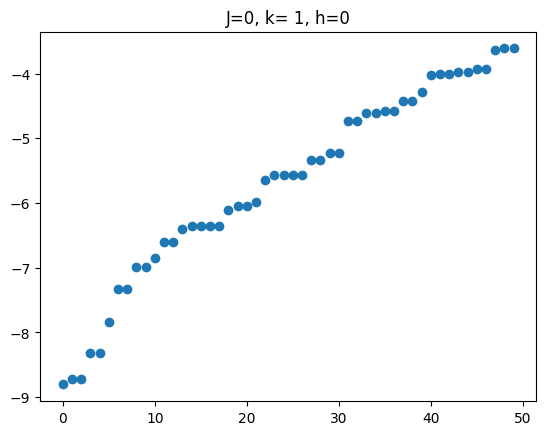

[np.float64(-88.04583417673486), np.float64(-87.2527643127783), np.float64(-87.2527643127783), np.float64(-83.20089146564764), np.float64(-83.20089146564764), np.float64(-78.3333696867271)]


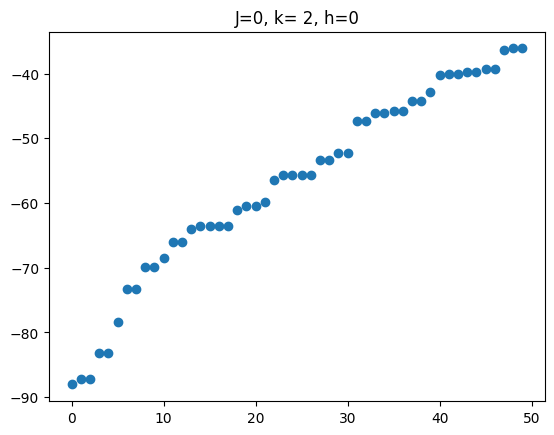

[np.float64(-17.60916683534694), np.float64(-17.45055286255569), np.float64(-17.450552862555647), np.float64(-16.64017829312957), np.float64(-16.64017829312956), np.float64(-15.666673937345408)]


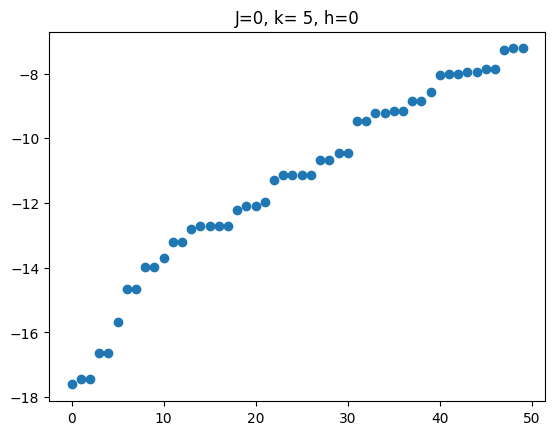

[np.float64(-44.02291708836743), np.float64(-43.62638215638915), np.float64(-43.62638215638915), np.float64(-41.60044573282382), np.float64(-41.60044573282382), np.float64(-39.16668484336355)]


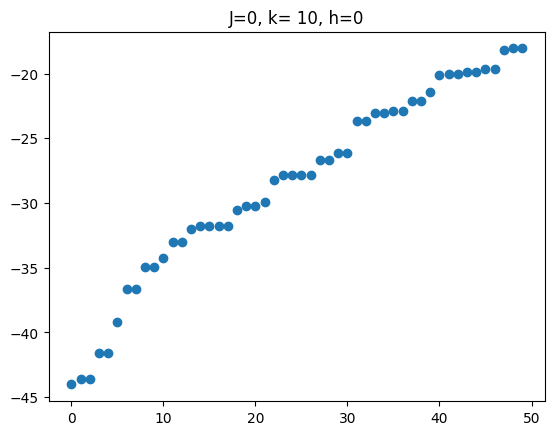

In [50]:
# plot energy spectrum
loc = os.path.join(os.getcwd(), f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values")
for (i, v) in zip(sorted(os.listdir(loc)), values):
    energy = np.loadtxt(os.path.join(loc, i))
    energy = sorted(energy)[:50]
    print(energy[:6])
    plt.scatter(range(len(energy)), energy)

    plt.title(f"J={J}, {scan_var}= {v}, {opp}={set}")
    plt.show()


In [182]:
results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"
var_num = len(values)

# --- entropy ---
single_site_entropy_curves = []
half_chain_entropy = []

# --- magnetization string ---
mx_list = np.zeros((var_num, L))
my_list = np.zeros((var_num, L))
mz_list = np.zeros((var_num, L))

# --- magnetization center ---
mz_mid_list=[]
my_mid_list=[]
mx_mid_list =[]

length = L//2
# --- correlation ---
xx_corr = np.zeros((var_num, length))
xy_corr = np.zeros((var_num, length))
xz_corr = np.zeros((var_num, length))
yy_corr = np.zeros((var_num, length))
yz_corr = np.zeros((var_num, length))
zz_corr = np.zeros((var_num, length))

for ind, i in tqdm(enumerate(sorted(os.listdir(results)))):
    psi = np.loadtxt(os.path.join(results,i), dtype=np.complex128)
        
    #--- Entanglement---
    single_site_entropy_curves.append(entanglement_string(psi, basis))
    half_chain_entropy.append(entanglement_site(psi, basis))

    # --- string measurements ---
    mx_list[ind] = magnetization_string('x', psi, basis)
    my_list[ind] = magnetization_string('y', psi, basis)
    mz_list[ind] = magnetization_string('z', psi, basis)

    # --- mid-chain measurements ---
    mz_mid_list.append(magnetization_site('z', length, psi, basis))
    my_mid_list.append(magnetization_site('y', length, psi, basis))
    mx_mid_list.append(magnetization_site('x', length, psi, basis, diff=True))

    # --- correlators ---
    xx_corr[ind] = correlator_string('x', 'x', length, psi, basis)
    xy_corr[ind] = correlator_string('x', 'y', length, psi, basis)
    xz_corr[ind] = correlator_string('x', 'z', length, psi, basis)
    yy_corr[ind] = correlator_string('y', 'y', length, psi, basis)
    yz_corr[ind] = correlator_string('y', 'z', length, psi, basis)
    zz_corr[ind] = correlator_string('z', 'z', length, psi, basis)

6it [00:00, 14.49it/s]


# DMRG

DMRG done using the code provided by Pietro Richelli @ https://www.github.com/pietrorichelli/dmrg


In [1]:
from dmrg_utils import *

In [6]:
def dmrg_main(L, par, pol, task_id = '0_0', J = 1):

    start_time = datetime.now()

    # Base output folder for this task
    base_path = task_id
    # os.makedirs(base_path, exist_ok=True)

    path_out = os.path.join(base_path, 'OUT')
    os.makedirs(path_out, exist_ok=True)
    path_mps = os.path.join(base_path, 'MPS')
    os.makedirs(path_mps, exist_ok=True)
    path_cont = os.path.join(base_path, 'CONT')
    os.makedirs(path_cont, exist_ok=True)

    # Define the system size and bond dimension
    L = L  # check
    chi = 200

    h_x, k_l, k_r = par

    # define the par output
    path_par = os.path.join(path_out, f'out_{h_x:.3f}_{k_l:.3f}_{k_r:.3f}/')
    os.makedirs(path_par, exist_ok=True)

    # initialise the MPS for the indicated chain length
    mps = MPS(L)

    # define the MPO 
    h = MPO_main(h=h_x,k_left=k_l, k_right=k_r, J=J, pol=pol)

    # define the contractions (it needs an mps and a MPO class as imputs)
    cont = CONT(mps=mps,H=h)

    # randomize initial MPS and CONT
    mps.random()
    cont.random()

    # Initialize your dmrg (set low bond dimension to make the system grow faster)
    sys = dmrg(cont=cont,chi=10,cut=1e-12)

    # Grow the system up to the desired dimension
    # En = sys.infinite()

    En = [0.0]
    # open the energy sweep file and write the starting energy
    with open(path_par + 'E_sweep.txt','w') as f:
        f.write(f'{En[-1]} \n')

    # Increase the bond dimension to the desired one 
    sys.chi = chi

    # run the first one and half sweep - do not record!
    for site,dir in mps.first_sweep():
        _,_,_ = sys.step2sites(site,dir=dir)
        
        # write sweep energy
        # with open(path_par + 'E_sweep.txt','a') as f:
        #     f.write(f'{E} \n')

    # Set up counter and energy check
    En_temp = np.zeros(2*L-8)
    En_temp[0] = 1

    # Now we can sweep the system  (ideally until convergence)
    sweep = 0
    while np.abs(En_temp[0] - En_temp[-1]) > 1e-7:
        j = 0
        for site,dir in mps.sweep():
            En_temp[j],S,_ = sys.step2sites(site,dir=dir)
            # write sweep energy
            with open(path_par + 'E_sweep.txt','a') as f:
                f.write(f'{En_temp[j]} \n')
            j +=1
        # increase system bond dimension for more accuracy
        # sys.chi += 100 - adds too much computation time

        if sweep >= 7:
             break
        
        sweep += 1

    # define observables
    obs = observables(mps)

    # Final sweep to store observables
    for site,dir in mps.right_sweep():
        En,S,_ = sys.step2sites(site,dir=dir,stage='Final')

        # Store local magnetization
        with open(path_par + 'X.txt','a') as fz:
                fz.write(f'{site} {obs.single_site(site,h.X).real} \n')
        with open(path_par + 'Y.txt', 'a') as fz:
                fz.write(f'{site} {obs.single_site(site,h.Y).real} \n')
        with open(path_par + 'Z.txt', 'a') as fz:
                fz.write(f'{site} {obs.single_site(site,h.Z).real} \n')

        # Store entanglement entropy
        with open(path_par + 'S.txt','a') as fz:
                fz.write(f'{site} {site+1} {S} \n')

        # Store all two point correlations from site
        obs.all_corr(path_par + 'XX.txt', site, string=h.Id , obs1=h.X)
        obs.all_corr(path_par + 'YY.txt', site, string=h.Id , obs1=h.Y)
        obs.all_corr(path_par + 'ZZ.txt', site, string=h.Id , obs1=h.Z)

        obs.all_corr(path_par + 'XZ.txt', site, string=h.Id , obs1=h.X, obs2=h.Z)
        obs.all_corr(path_par + 'XY.txt', site, string=h.Id , obs1=h.X, obs2=h.Y)
        obs.all_corr(path_par + 'YZ.txt', site, string=h.Id , obs1=h.Y, obs2=h.Z)

        obs.all_corr(path_par + 'XYZ.txt',site, string=h.Y, obs1=h.X, obs2=h.Z)

    end_time = datetime.now()
    diff = end_time - start_time
    total_seconds = int(diff.total_seconds())

    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60

    print(f'Parameter ({h_x:.3f}, {k_l:.3f}, {k_r:.3f}) done !!! Time elapsed: {hours:02}:{minutes:02}:{seconds:02}')

def dmrg_line(L, pol, scan_var, values, opp, set, home, J=1):
    ''' Perform a single line of parameter values for DMRG'''

    folder = f"dmrg_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}"
    if os.path.exists(os.path.join(os.getcwd(), folder)):
        return 1
    # determine h and k
    for ind, val in tqdm(enumerate(values)):
        if scan_var == "h":
            h = val
            k_l = k_r = set
        else:
            h = set     # fixed field, change if needed
            k_l = k_r = val

        # create folder for results
        task_id = f"L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}/{h:.2f}_{k_l:.2f}_{k_r:.2f}"
        workdir = f"run_{task_id}"
        os.makedirs(workdir, exist_ok=True)
        os.chdir(workdir)

        parameter = (h,k_l,k_r)
        dmrg_main(L, parameter, pol, task_id='.', J=J)

        os.chdir("../..")
    
    # go back home
    os.chdir(home)

In [7]:
pol = "tot"
home = os.getcwd()

if not os.path.exists(os.path.join(os.getcwd(), "dmrg_results")):
    os.mkdir(os.path.join(os.getcwd(), "dmrg_results"))
os.chdir(os.path.join(os.getcwd(), "dmrg_results"))

dmrg_line(L, pol, scan_var=scan_var, values=values, opp=opp, set=set, home=home, J=0)

0it [04:41, ?it/s]


KeyboardInterrupt: 

# Compare DMRG w/ ED

In [183]:
# fetch the file you are studying
filename = f"run_L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}"
print(filename)
filename = os.path.join(os.getcwd(), "dmrg_results", filename)

run_L12_h0_k0.05-0.3


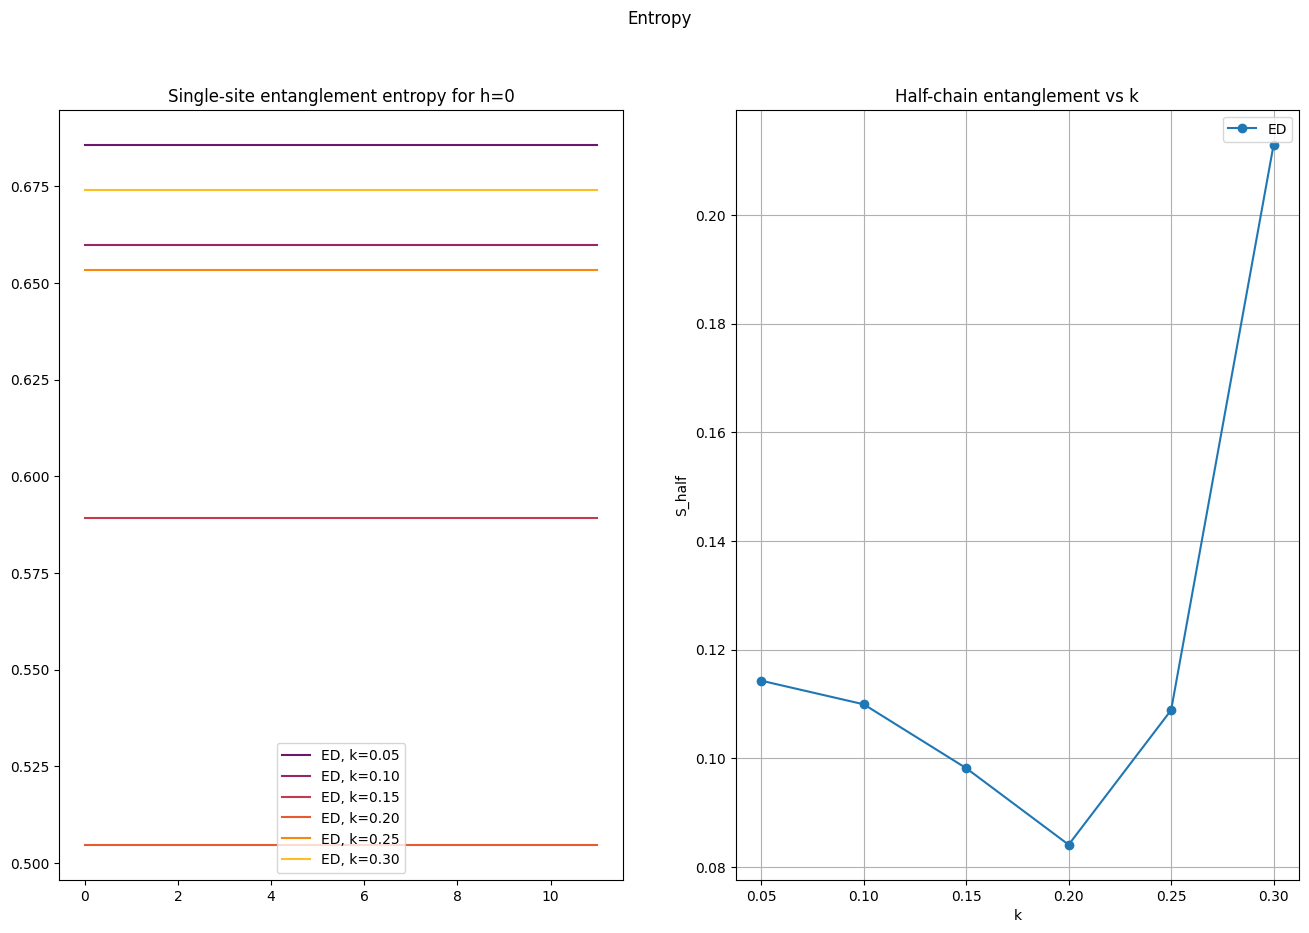

In [184]:
# --- entropy ---
def plot_entropy(dmrg_path, single_site, half_chain, scan_var, values, opp, set):
    fig, ax = plt.subplots(1, 2, figsize=(16, 10))
    fig.suptitle("Entropy")

    s_mid = []

    cmap = plt.cm.inferno
    colors = cmap(np.linspace(0.3, 0.85, len(values)))

    for i, (v, c) in enumerate(zip(values, colors)):
        if scan_var == "h":
            loc = os.path.join(dmrg_path, f"{v:.2f}_{set:.2f}_{set:.2f}/OUT/out_{v:.3f}_{set:.3f}_{set:.3f}/S.txt")
        else:
            loc = os.path.join(dmrg_path, f"{set:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set:.3f}_{v:.3f}_{v:.3f}/S.txt")

        try:
            ind, _, s = np.loadtxt(loc, dtype=np.complex128).T
            mid_site = len(s) // 2
            s_mid.append(s[mid_site])
            ax[0].plot(ind, s, ls="--", color=c)  # DMRG
        except Exception:
            # No DMRG data → skip plotting
            pass

        ax[0].plot(single_site[i], color=c, label=f"ED, {scan_var}={v:.2f}")

    ax[0].set_title(f"Single-site entanglement entropy for {opp}={set}")
    ax[0].legend()

    # --- half-chain entropy compare ---
    ax[1].plot(values, half_chain, "-o", label="ED")
    if len(s_mid) == len(values):
        ax[1].plot(values, s_mid, "x-", color="red", label="DMRG")

    ax[1].set_title(f"Half-chain entanglement vs {scan_var}")
    ax[1].set_xlabel(f"{scan_var}")
    ax[1].set_ylabel("S_half")
    ax[1].legend()

    plt.grid()
    plt.show()


plot_entropy(filename, single_site_entropy_curves, half_chain_entropy, values=values, scan_var=scan_var, opp=opp, set=set)

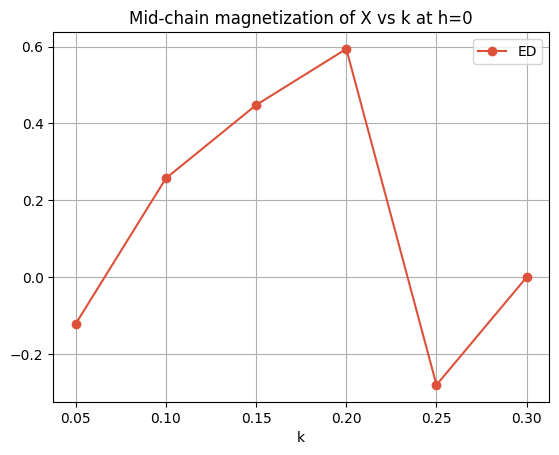

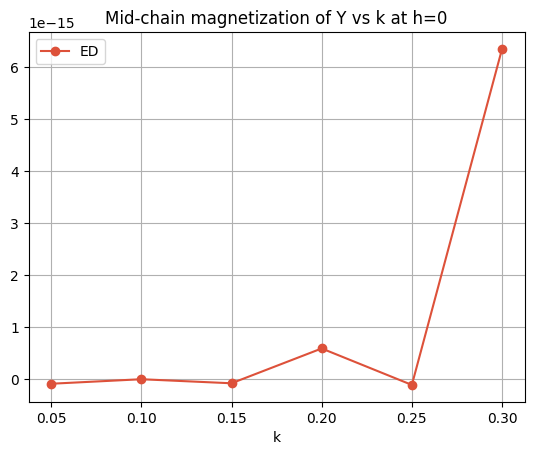

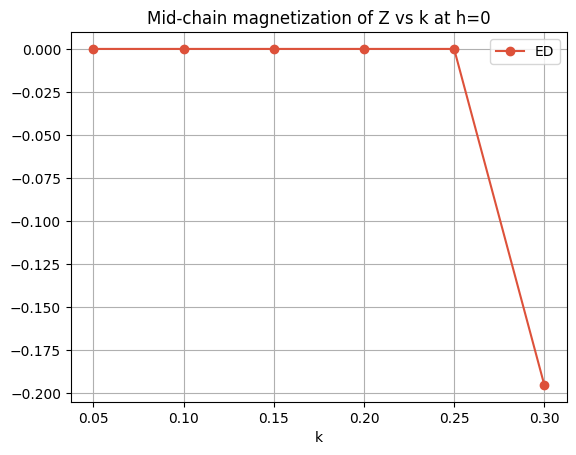

In [185]:
# --- site magnetization ---
def plot_site(dmrg_path, op, values, site_measurements_ed, scan_var, opp, set):
    cmap = plt.cm.inferno
    cmap2 = plt.cm.viridis
    color = cmap(0.6)
    color2 = cmap2(0.6)

    site_measurements_dmrg = []
    loc = os.path.join(dmrg_path, f"*/OUT/*/{op}.txt")

    dmrg_files = sorted(glob.glob(loc))

    for i in dmrg_files:
        try:
            r = np.loadtxt(i).T[1]
            if op == "X":
                site_measurements_dmrg.append(0.5*(r[int(len(r)//2)]-r[int(len(r)//2)+1]))
            else:
                site_measurements_dmrg.append(r[int(len(r)//2)])
        except Exception:
            continue   # skip missing or broken files

    # --- always plot ED ---
    plt.plot(values, site_measurements_ed, "-o", color=color,label="ED")

    # --- plot DMRG only if available ---
    if len(site_measurements_dmrg) == len(values):
        plt.plot(values, site_measurements_dmrg, "-x", color=color2, label="DMRG")

    plt.title(f"Mid-chain magnetization of {op} vs {scan_var} at {opp}={set}")
    plt.xlabel(scan_var)
    plt.legend()
    plt.grid()
    plt.show()

plot_site(filename, 'X', values, mx_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site(filename, 'Y', values, my_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site(filename, 'Z', values, mz_mid_list, scan_var=scan_var, opp=opp, set=set)

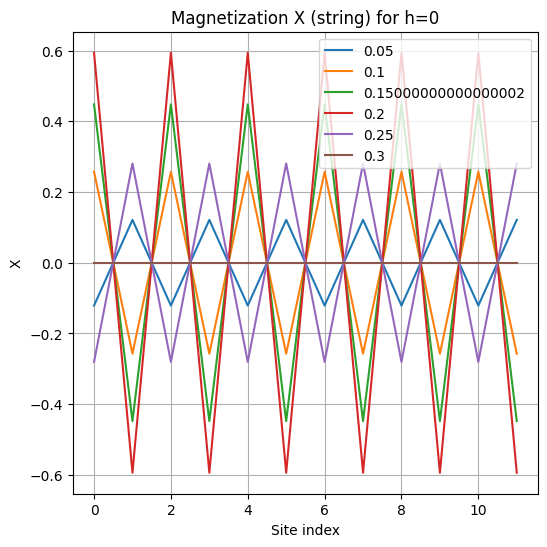

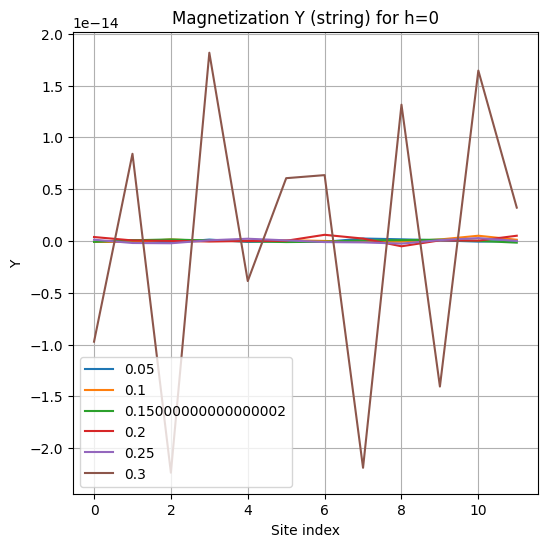

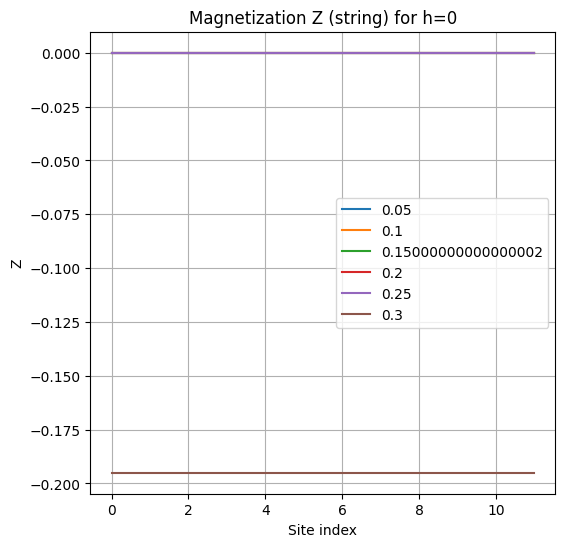

In [192]:
# --- string magnetization ----
def plot_string(dmrg_path, op, values, string_measurements_ed, scan_var, opp, set):
    cmap = plt.cm.inferno
    colors = cmap(np.linspace(0, 0.5, len(values)))
    plt.figure(figsize=(6, 6))
    for ind, (v, c) in enumerate(zip(values, colors)):
        

        if scan_var == "h":
            loc = os.path.join(dmrg_path, f"{v:.2f}_{set:.2f}_{set:.2f}/OUT/out_{v:.3f}_{set:.3f}_{set:.3f}/{op}.txt")
        else:
            loc = os.path.join(dmrg_path, f"{set:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set:.3f}_{v:.3f}_{v:.3f}/{op}.txt")

        # --- Try loading DMRG file ---
        try:
            index_dmrg, site_measurements_dmrg = np.loadtxt(loc).T
            has_dmrg = True
        except Exception:
            has_dmrg = False

        # --- ED ---
        plt.plot(
            range(len(string_measurements_ed.T)),
            string_measurements_ed[ind],
            label=f"{v}"
        )

        # --- DMRG (optional) ---
        if has_dmrg:
            plt.scatter(
                index_dmrg,
                site_measurements_dmrg,
                marker="x",
                color="black",
                label="DMRG"
            )

    plt.title(f"Magnetization {op} (string) for {opp}={set}")
    plt.xlabel("Site index")
    plt.ylabel(f"{op}")
    plt.legend()
    plt.grid()
    plt.show()


plot_string(filename, 'X', values, mx_list, scan_var=scan_var, opp=opp, set=set)
plot_string(filename, 'Y', values, my_list, scan_var=scan_var, opp=opp, set=set)
plot_string(filename, 'Z', values, mz_list, scan_var=scan_var, opp=opp, set=set)

/tmp/ipykernel_31665/566303780.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


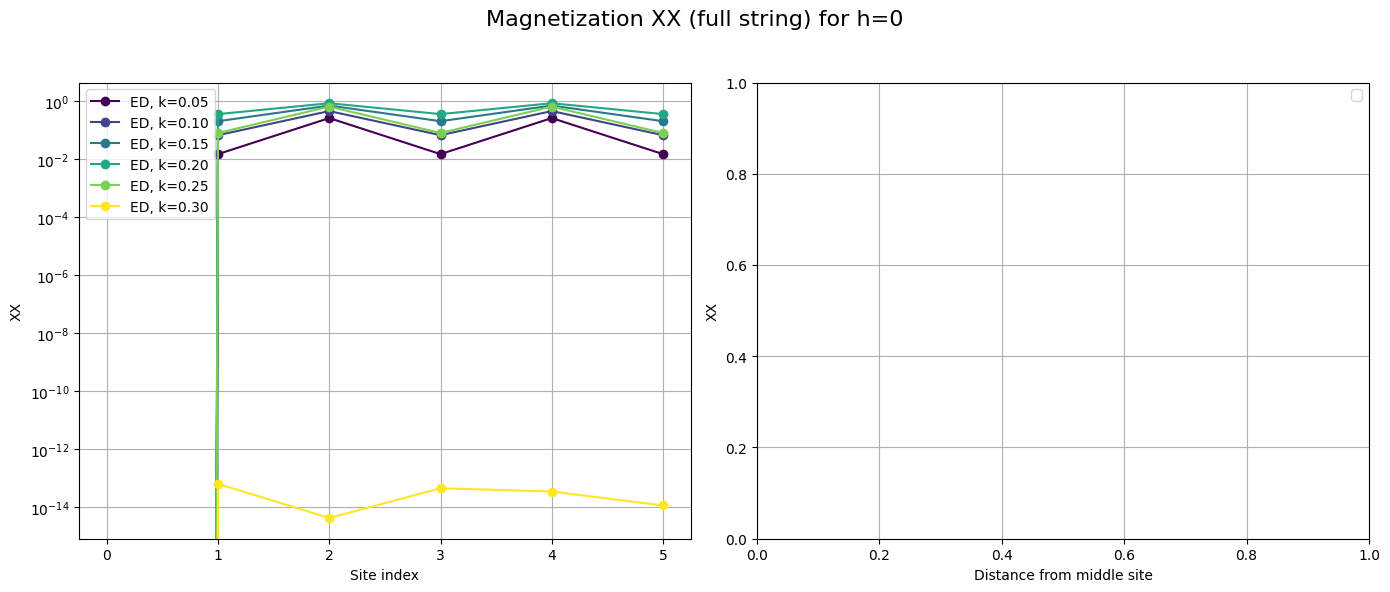

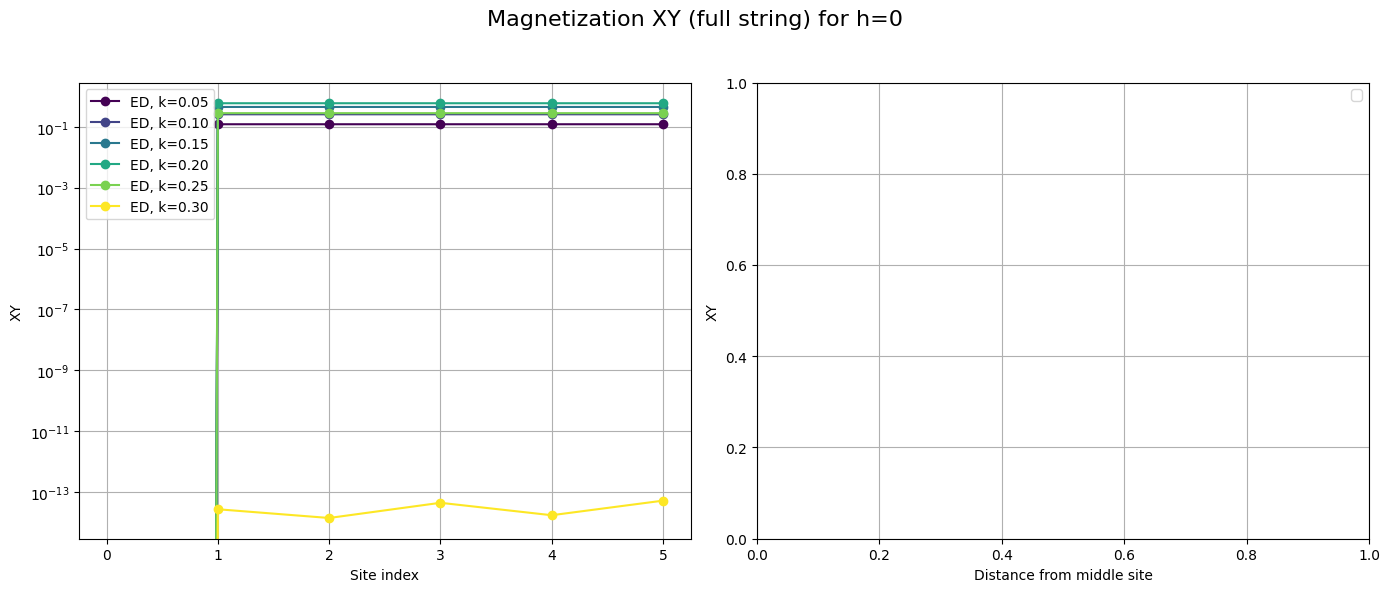

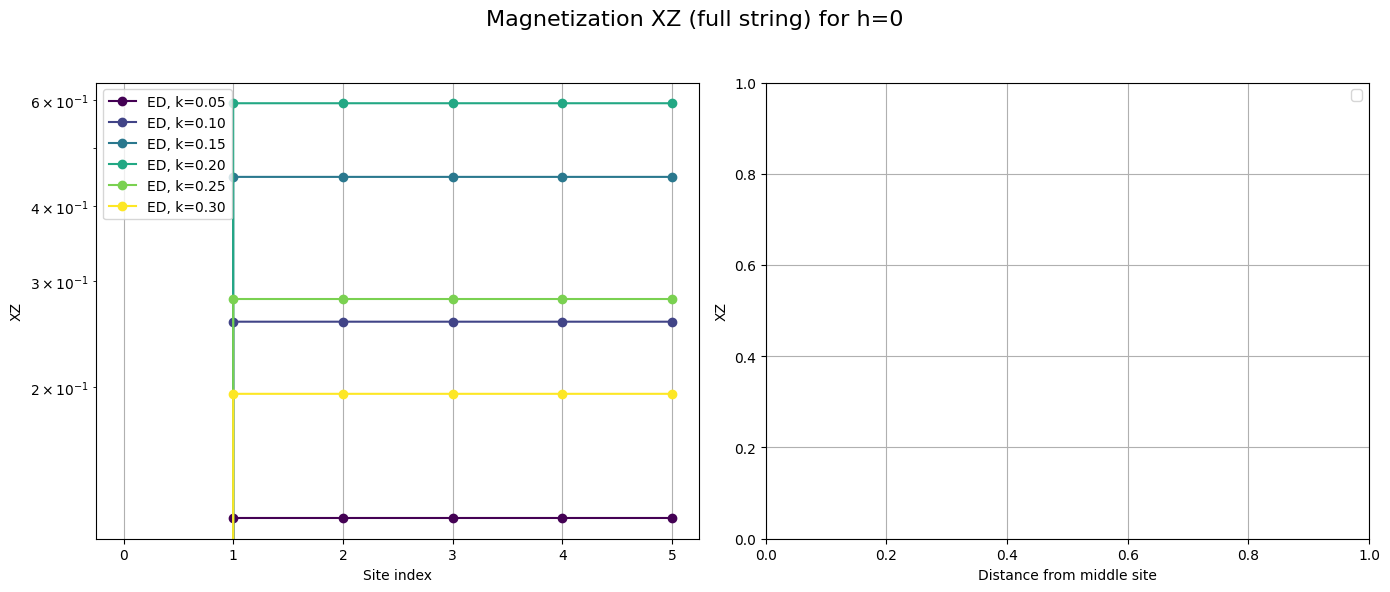

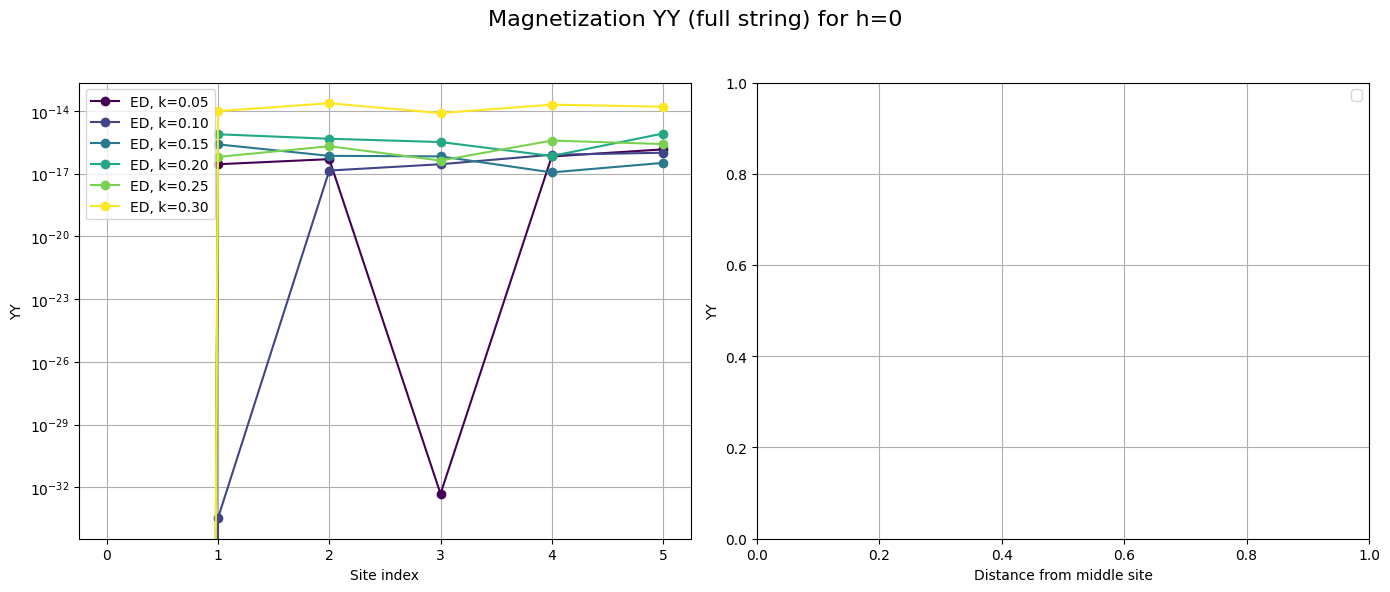

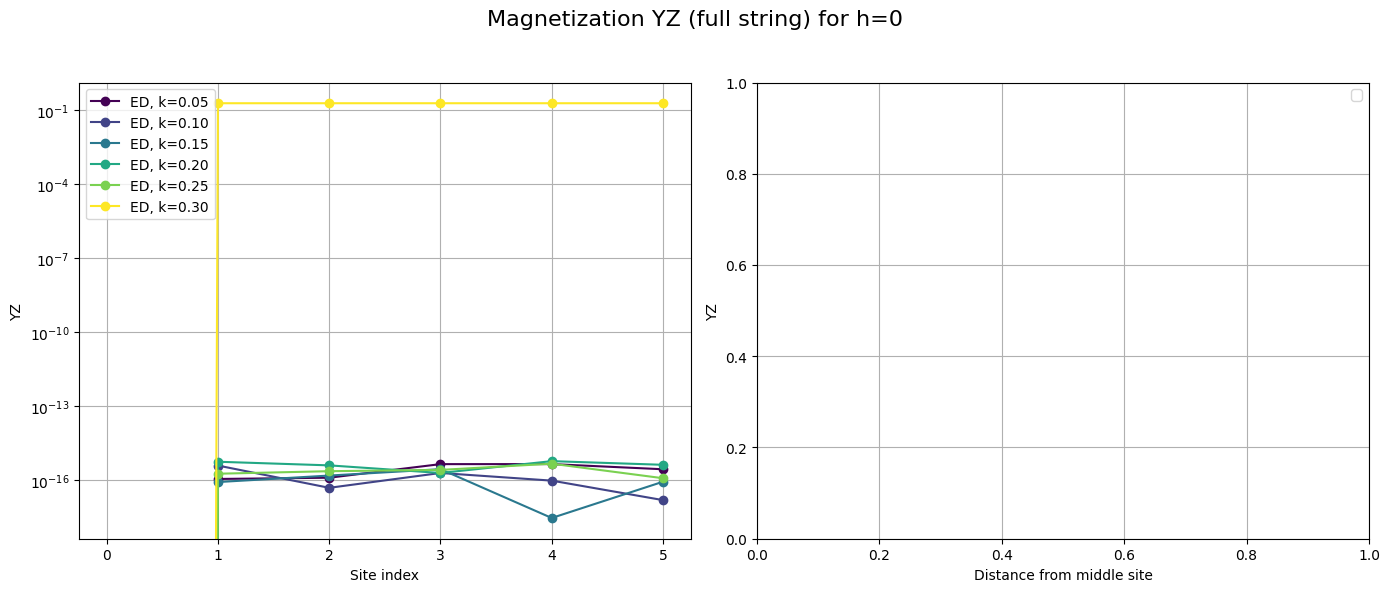

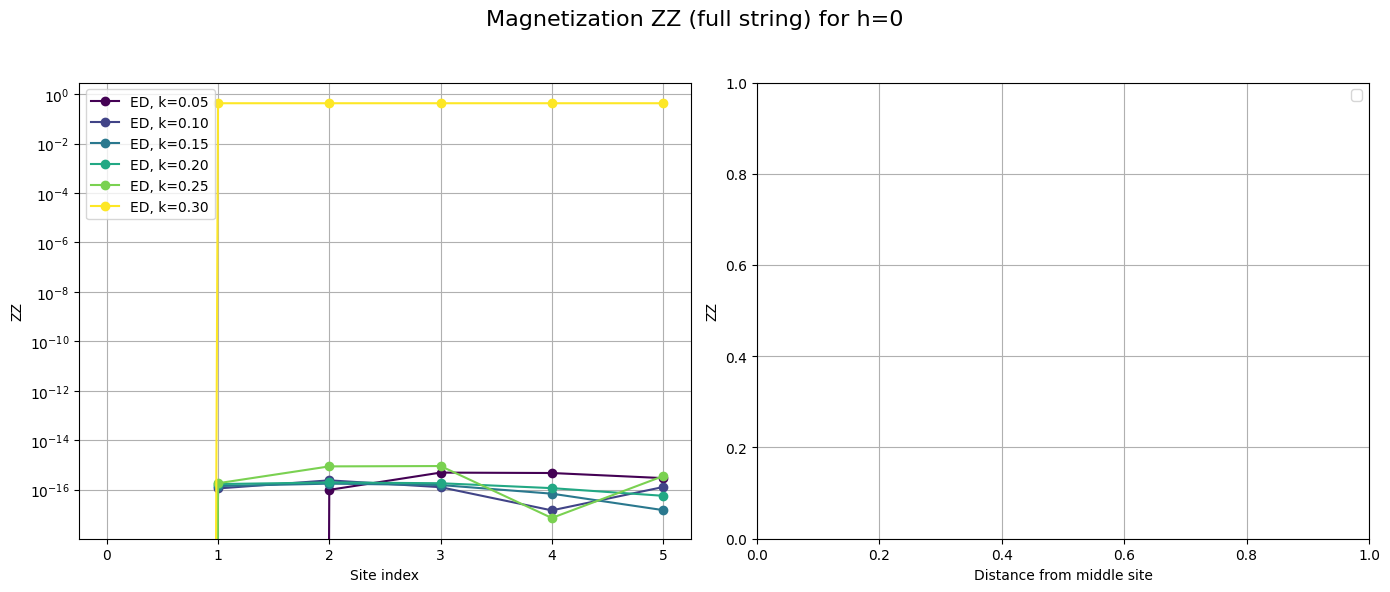

In [199]:
def plot_correlator(dmrg_path, op, values, measurements_ed, scan_var, opp, set, orientation="semilogy"):
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Magnetization {op} (full string) for {opp}={set}", fontsize=16)

    # Choose colormaps
    cmap_ed = plt.cm.viridis
    cmap_dmrg = plt.cm.inferno
    colors_ed = cmap_ed(np.linspace(0, 1, len(values)))
    colors_dmrg = cmap_dmrg(np.linspace(0, 1, len(values)))

    for ind, (v, c_ed, c_dmrg) in enumerate(zip(values, colors_ed, colors_dmrg)):
        # ED data
        L = measurements_ed.shape[1]
        y_ed = np.abs(measurements_ed[ind])
        x_ed = [L - i - 1 for i in range(L)] 
        # x_ed = np.arange(1, len(y_ed)+1+1)
        label_ed = f"{scan_var}={v:.2f}"

        # DMRG data
        if scan_var == "h":
            loc = os.path.join(dmrg_path, f"{v:.2f}_{set:.2f}_{set:.2f}/OUT/out_{v:.3f}_{set:.3f}_{set:.3f}/{op}.txt")
        else:
            loc = os.path.join(dmrg_path, f"{set:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set:.3f}_{v:.3f}_{v:.3f}/{op}.txt")

        r = np.loadtxt(loc, dtype=np.complex128)
        x_dmrg, y_dmrg = [], []

        # Extract correlations starting from middle site
        for i, j, corr in r:
            if i == L:
                x_dmrg.append(j - i)
                y_dmrg.append(np.abs(corr))

        # Plot depending on orientation
        if orientation == "semilogy":
            ax[0].semilogy(x_ed, y_ed, "-o", color=c_ed, label="ED, " + label_ed)
            ax[1].semilogy(x_dmrg, y_dmrg, "-x", color=c_dmrg, label="DMRG, " + label_ed)
        elif orientation == "loglog":
            ax[0].loglog(x_ed, y_ed, "-o", color=c_ed, label="ED, " + label_ed)
            ax[1].loglog(x_dmrg, y_dmrg, "-x", color=c_dmrg, label="DMRG, " + label_ed)
        else:
            ax[0].plot(x_ed, y_ed, "-o", color=c_ed, label="ED, " + label_ed)
            ax[1].plot(x_dmrg, y_dmrg, "-x", color=c_dmrg, label="DMRG, " + label_ed)

    # Labels, grid, legends
    ax[0].set_xlabel("Site index")
    ax[0].set_ylabel(f"{op}")
    ax[0].grid(True)
    ax[0].legend()

    ax[1].set_xlabel("Distance from middle site")
    ax[1].set_ylabel(f"{op}")
    ax[1].grid(True)
    ax[1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
    plt.show()


def plot_correlator(dmrg_path, op, values, measurements_ed, scan_var, opp, set_val, orientation="semilogy"):
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Magnetization {op} (full string) for {opp}={set_val}", fontsize=16)

    # Colormaps
    cmap_ed = plt.cm.viridis
    cmap_dmrg = plt.cm.inferno
    colors_ed = cmap_ed(np.linspace(0, 1, len(values)))
    colors_dmrg = cmap_dmrg(np.linspace(0, 1, len(values)))

    L = measurements_ed.shape[1]

    for ind, (v, c_ed, c_dmrg) in enumerate(zip(values, colors_ed, colors_dmrg)):
        # ---------------- ED DATA ----------------
        y_ed = np.abs(measurements_ed[ind])
        x_ed = [L - i - 1 for i in range(L)]  # reverse order
        label_ed = f"{scan_var}={v:.2f}"
        ax_ed = ax[0]

        # ---------------- DMRG DATA ----------------
        if scan_var == "h":
            loc = os.path.join(dmrg_path, f"{v:.2f}_{set_val:.2f}_{set_val:.2f}/OUT/out_{v:.3f}_{set_val:.3f}_{set_val:.3f}/{op}.txt")
        else:
            loc = os.path.join(dmrg_path, f"{set_val:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set_val:.3f}_{v:.3f}_{v:.3f}/{op}.txt")

        x_dmrg, y_dmrg = [], []

        if os.path.exists(loc):
            try:
                r = np.loadtxt(loc, dtype=np.complex128)
                if r.ndim == 1:
                    r = r.reshape(1, -1)  # single-row file
                for row in r:
                    i, j, corr = row
                    # Choose correlations relative to middle site
                    if int(i) == L//2:
                        x_dmrg.append(int(j) - int(i))
                        y_dmrg.append(np.abs(corr))
            except Exception as e:
                print(f"Warning: failed to read {loc}: {e}")
        else:
            print(f"Warning: file not found {loc}")

        # ---------------- PLOTTING ----------------
        if orientation == "semilogy":
            ax[0].semilogy(x_ed, y_ed, "-o", color=c_ed, label="ED, " + label_ed)
            if x_dmrg:
                ax[1].semilogy(x_dmrg, y_dmrg, "-x", color=c_dmrg, label="DMRG, " + label_ed)
        elif orientation == "loglog":
            ax[0].loglog(x_ed, y_ed, "-o", color=c_ed, label="ED, " + label_ed)
            if x_dmrg:
                ax[1].loglog(x_dmrg, y_dmrg, "-x", color=c_dmrg, label="DMRG, " + label_ed)
        else:
            ax[0].plot(x_ed, y_ed, "-o", color=c_ed, label="ED, " + label_ed)
            if x_dmrg:
                ax[1].plot(x_dmrg, y_dmrg, "-x", color=c_dmrg, label="DMRG, " + label_ed)

    # ---------------- AXIS LABELS & GRID ----------------
    ax[0].set_xlabel("Site index")
    ax[0].set_ylabel(f"{op}")
    ax[0].grid(True)
    ax[0].legend()

    ax[1].set_xlabel("Distance from middle site")
    ax[1].set_ylabel(f"{op}")
    ax[1].grid(True)
    ax[1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
# --- correlations ---
plot_correlator(filename, 'XX', values, xx_corr, scan_var=scan_var, opp=opp, set_val=set)
plot_correlator(filename, 'XY', values, xy_corr, scan_var=scan_var, opp=opp, set_val=set)
plot_correlator(filename, 'XZ', values, xz_corr, scan_var=scan_var, opp=opp, set_val=set)
plot_correlator(filename, 'YY', values, yy_corr, scan_var=scan_var, opp=opp, set_val=set)
plot_correlator(filename, 'YZ', values, yz_corr, scan_var=scan_var, opp=opp, set_val=set)
plot_correlator(filename, 'ZZ', values, zz_corr, scan_var=scan_var, opp=opp, set_val=set)